Name: **MOODU ROOPA**

Enrollment ID: **2022CSB087**

In [3]:
import heapq
import math


class Cell:
    def __init__(self,x,y,z):
        self.x=x
        self.y=y
        self.z=z

    def __eq__(self,other):
        return (self.x,self.y,self.z)==(other.x,other.y,other.z)

    def __hash__(self):
        return hash((self.x,self.y,self.z))

    def __lt__(self,other):
        return (self.x,self.y,self.z)<(other.x,other.y,other.z)


class DroneRescue:

    def __init__(self,ground,mid,sky):

        self.grid=[ground,mid,sky]

        self.rows=len(ground)
        self.cols=len(ground[0])
        self.levels=3

        self.NORMAL_COST=1
        self.FIRE_COST=3
        self.CLIMB_COST=2
        self.DESCEND_COST=1


    def get_neighbors(self,cell):

        directions=[
        (0,0,1),
        (0,0,-1),
        (-1,0,0),
        (1,0,0),
        (0,1,0),
        (0,-1,0)
        ]

        neighbors=[]

        for dx,dy,dz in directions:

            nx=cell.x+dx
            ny=cell.y+dy
            nz=cell.z+dz

            if 0<=nx<self.rows and 0<=ny<self.cols and 0<=nz<self.levels:

                if self.grid[nz][nx][ny]!="1":

                    cost=self.NORMAL_COST

                    if dz==1:
                        cost+=self.CLIMB_COST

                    if dz==-1:
                        cost+=self.DESCEND_COST

                    if self.grid[nz][nx][ny]=="F":
                        cost+=self.FIRE_COST

                    neighbors.append((Cell(nx,ny,nz),cost))

        return neighbors


    def heuristic(self,a,b):

        return math.sqrt(
        (a.x-b.x)**2+
        (a.y-b.y)**2+
        (a.z-b.z)**2
        )


    def astar(self,start,goal):

        frontier=[]
        heapq.heappush(frontier,(0,start))

        came_from={}
        g_score={start:0}

        while frontier:

            _,current=heapq.heappop(frontier)

            if current==goal:

                path=[]
                while current in came_from:
                    path.append(current)
                    current=came_from[current]

                path.append(start)
                path.reverse()

                return path,g_score[goal]

            for next_cell,cost in self.get_neighbors(current):

                new_cost=g_score[current]+cost

                if next_cell not in g_score or new_cost<g_score[next_cell]:

                    g_score[next_cell]=new_cost
                    f=new_cost+self.heuristic(next_cell,goal)

                    heapq.heappush(frontier,(f,next_cell))
                    came_from[next_cell]=current

        return None,float("inf")


    def scan_grid(self):

        start=None
        base=None
        goals=[]
        recharge=[]

        for z in range(self.levels):
            for i in range(self.rows):
                for j in range(self.cols):

                    val=self.grid[z][i][j]

                    if val=="S":
                        start=Cell(i,j,z)

                    if val=="B":
                        base=Cell(i,j,z)

                    if "G" in val:
                        goals.append(Cell(i,j,z))

                    if val=="R":
                        recharge.append(Cell(i,j,z))

        return start,goals,base,recharge


    def rescue(self):

        start,goals,base,_=self.scan_grid()

        current=start
        total_path=[start]
        total_cost=0

        remaining=goals.copy()

        while remaining:

            best_goal=None
            best_path=None
            best_cost=float("inf")

            for g in remaining:

                path,cost=self.astar(current,g)

                if cost<best_cost:
                    best_cost=cost
                    best_goal=g
                    best_path=path

            total_path+=best_path[1:]
            total_cost+=best_cost

            current=best_goal
            remaining.remove(best_goal)

        path,cost=self.astar(current,base)

        total_path+=path[1:]
        total_cost+=cost

        return total_path,total_cost



# -----------------------------
# Grid
# -----------------------------

ground=[
['S','0','1','0','0'],
['0','F','1','1','G1'],
['F','0','0','0','F'],
['R','1','1','1','0'],
['B','0','1','0','G2']
]

mid=[
['0','0','1','0','0'],
['0','1','1','0','0'],
['F','0','0','0','1'],
['0','1','1','1','0'],
['0','0','0','0','0']
]

sky=[
['1','0','0','0','0'],
['0','F','0','1','0'],
['0','0','1','0','F'],
['0','0','0','0','0'],
['0','1','0','0','1']
]


drone=DroneRescue(ground,mid,sky)

path,total_cost=drone.rescue()


# -------------------------------------------------
# PRINT DETAILED OUTPUT (LIKE THE PDF)
# -------------------------------------------------

print("\nOptimal Path Using A*:")

for i,cell in enumerate(path):

    desc=""

    if i==0:
        desc='→ "S"'

    elif ground[cell.x][cell.y]=="R" and cell.z==0:
        desc="→ Recharge at (R)"

    elif "G" in ground[cell.x][cell.y]:
        desc=f"→ Rescue {ground[cell.x][cell.y]}"

    elif ground[cell.x][cell.y]=="F":
        desc="→ Fire zone"

    else:
        desc="→ Free space"

    print(f"{i+1}. Move to ({cell.x},{cell.y},{cell.z}) {desc}")


# -------------------------------------------------
# ENERGY BREAKDOWN
# -------------------------------------------------

free_moves=0
fire_moves=0
climb=0
descend=0

for i in range(1,len(path)):

    prev=path[i-1]
    cur=path[i]

    if cur.z>prev.z:
        climb+=1

    elif cur.z<prev.z:
        descend+=1


    cell = drone.grid[cur.z][cur.x][cur.y]

    if cell=="F":
        fire_moves+=1
    else:
        free_moves+=1


print("\nEnergy Consumption Calculation:")

print(f"- Moving through free space: {free_moves} × 1 energy = {free_moves}")
print(f"- Moving through fire zones: {fire_moves} × 3 energy = {fire_moves*3}")
print(f"- Climbing (z+1): {climb} × 2 energy = {climb*2}")
print(f"- Descending (z-1): {descend} × 1 energy = {descend*1}")

print(f"\nTotal Energy Used: {total_cost} units")


print("\nFinal Summary:")

path_str=" → ".join(f"({c.x},{c.y},{c.z})" for c in path)

print("Optimal Path:",path_str)
print("Total Energy Consumption:",total_cost,"units")
print("Mission Completion: Success! The drone returned to base B!")


Optimal Path Using A*:
1. Move to (0,0,0) → "S"
2. Move to (0,1,0) → Free space
3. Move to (1,1,0) → Fire zone
4. Move to (2,1,0) → Free space
5. Move to (2,2,0) → Free space
6. Move to (2,3,0) → Free space
7. Move to (2,4,0) → Fire zone
8. Move to (1,4,0) → Rescue G1
9. Move to (2,4,0) → Fire zone
10. Move to (3,4,0) → Free space
11. Move to (4,4,0) → Rescue G2
12. Move to (4,3,0) → Free space
13. Move to (4,3,1) → Free space
14. Move to (4,2,1) → Free space
15. Move to (4,1,1) → Free space
16. Move to (4,0,1) → Free space
17. Move to (4,0,0) → Free space

Energy Consumption Calculation:
- Moving through free space: 13 × 1 energy = 13
- Moving through fire zones: 3 × 3 energy = 9
- Climbing (z+1): 1 × 2 energy = 2
- Descending (z-1): 1 × 1 energy = 1

Total Energy Used: 28 units

Final Summary:
Optimal Path: (0,0,0) → (0,1,0) → (1,1,0) → (2,1,0) → (2,2,0) → (2,3,0) → (2,4,0) → (1,4,0) → (2,4,0) → (3,4,0) → (4,4,0) → (4,3,0) → (4,3,1) → (4,2,1) → (4,1,1) → (4,0,1) → (4,0,0)
Total Ener

🟢 Start (S)

🔴 Survivors (G)

🔵 Base (B)

🟠 Fire zones (F)

🟣 Recharge stations (R)

⚫ Buildings (1)

🟡 Drone path

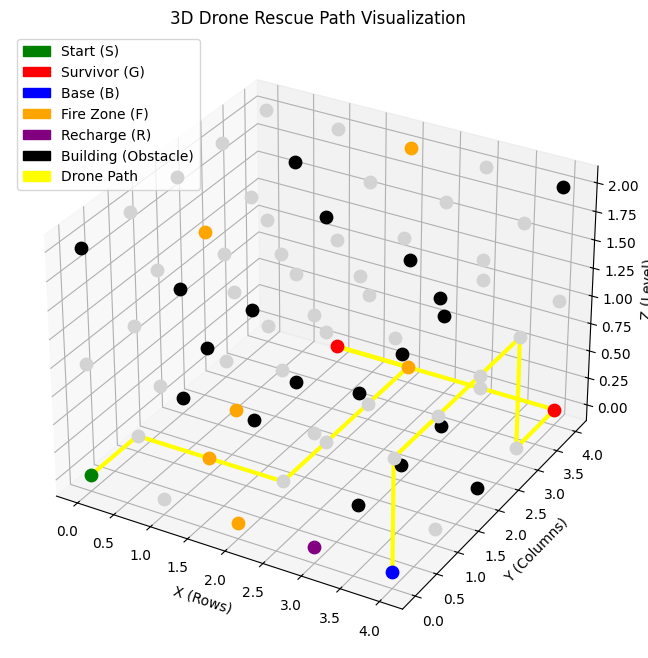

In [6]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches

def visualize_3d_path(ground, mid, sky, path):

    grids = [ground, mid, sky]

    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')

    colors = {
        'S':'green',
        'B':'blue',
        'F':'orange',
        'R':'purple',
        'G':'red',
        '1':'black',
        '0':'lightgray'
    }

    # Plot grid cells
    for z in range(3):
        for x in range(len(grids[z])):
            for y in range(len(grids[z][0])):

                cell = grids[z][x][y]

                if 'G' in cell:
                    c = colors['G']
                else:
                    c = colors.get(cell, 'lightgray')

                ax.scatter(x, y, z, color=c, s=80)

    # Plot drone path
    px = [p.x for p in path]
    py = [p.y for p in path]
    pz = [p.z for p in path]

    ax.plot(px, py, pz, color='yellow', linewidth=3)

    ax.set_xlabel("X (Rows)")
    ax.set_ylabel("Y (Columns)")
    ax.set_zlabel("Z (Level)")

    ax.set_title("3D Drone Rescue Path Visualization")

    # Legend
    legend_elements = [
        mpatches.Patch(color='green', label='Start (S)'),
        mpatches.Patch(color='red', label='Survivor (G)'),
        mpatches.Patch(color='blue', label='Base (B)'),
        mpatches.Patch(color='orange', label='Fire Zone (F)'),
        mpatches.Patch(color='purple', label='Recharge (R)'),
        mpatches.Patch(color='black', label='Building (Obstacle)'),
        mpatches.Patch(color='yellow', label='Drone Path')
    ]

    ax.legend(handles=legend_elements, loc="upper left")

    plt.show()


# Call visualization
visualize_3d_path(ground, mid, sky, path)